<a href="https://colab.research.google.com/github/Jette-j/Computervision/blob/main/exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision
## Exercise Sheet 1: Imaging
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. Jette Jensen
2.
3.
4.
5.


In [40]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

In [41]:
import cv2 # open cv
import matplotlib.pyplot as plt # plotting tools
import numpy as np # matrix, array operations
import requests


from os.path import join # combine different items to a path
from os import getcwd, listdir # shows the current directory, lists items in a directory

# show plots when running cell
%matplotlib inline

## Exercise 1.1
### Loading and displaying images in Python
Download the image `clown.png` from the website of the tutorial. Load
the image in Python via opencv (`cv2.imread`). By default the image is loaded as BGR (blue, green, red), convert the image to gray with `cv2.cvtColor`.
Display the image `plt.imshow`, use the colormap `gray`.

In [42]:

import re
import json

DRIVE_LINKS = {
    'thin_lens':"https://drive.google.com/file/d/1-Wu6CkCwgJkMWUdb20UkFsBjXBvLCJ3V/view?usp=sharing",
    'cam_model':"https://drive.google.com/file/d/1TZT2lNjms_CrNBQGC3G3pI3XPZ3iMR3j/view?usp=sharing",
    'clown':"https://drive.google.com/file/d/135l8Bn33VvFTZdsc7UnVtSZ27qeLhX7A/view?usp=sharing",
    'ueb131': "https://drive.google.com/file/d/1sUan0g2d3tH9ctysBzD5rh5EUCSjBvWt/view?usp=sharing",
    'ueb132': "https://drive.google.com/file/d/1u4mAU8HXX-1-8N55g1lfBBs3V-5yhSDP/view?usp=sharing"
}

# Modified RGX to handle both 'usp=sharing' and 'usp=drive_link'
RGX = r'https:\/\/drive.google.com\/file\/d\/(.*)\/view\?usp=(?:sharing|drive_link)'

def run():
    output = dict()
    for key, val in DRIVE_LINKS.items():
        match = re.match(RGX, val)
        assert bool(match), key
        im_id = match.group(1)

        new_link = "https://drive.google.com/uc?id=" + im_id
        output[key] = new_link

    with open("markdown_links.json", "w") as file:
        json.dump(output, file)

if __name__ == "__main__":
    run()

In [51]:
def load_image_from_link(key):
    with open('markdown_links.json', 'r') as f:
        links = json.load(f)
    image_path = links[key]

    response = requests.get(image_path)
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp_file:
        tmp_file.write(response.content)
        tmp_file.flush()
        temp_file_path = tmp_file.name

    image = cv2.imread(temp_file_path)
    return image

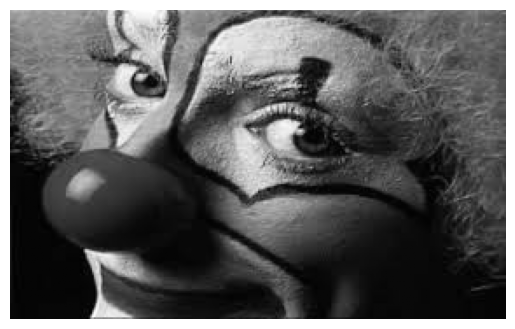

In [52]:
import tempfile # Import the tempfile module

# TODO: define image path (load json + choose link)
image =load_image_from_link('clown')
# TODO: convert image to grayscale
grey_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# TODO: display image
#print(image,'path')
#print(f"Height:\t\t {image[0]}")
#print(f"Width:\t\t {image[1]}")
plt.imshow(grey_image,cmap='grey')
plt.axis('off')
plt.show()

# Optional: Clean up the temporary file after use
#import os
#os.remove(temp_file_path)

## Exercise 1.2
### Image gradients
Images are stored as `numpy arrays`, for further computations convert the array to range $[0, 1]$ (`astype`). Define a function `load_gray_normalized` that loads the image, converts it to grayscale and normalizes it.
Compute the image gradients $d_x$ and $d_y$ for the image from the previous assignment. Initialize a simple gradient kernel like $[-1, 0, +1]$ for $d_x$ (`np.zeros`, `np.array`) and filter the image with it (`cv2.filter2D`). Visualize the results using `plt.imshow`. To this end, display the resulting images of both derivatives along `x` and `y` in a single figure (`plt.subplots`).

What do you need to take care of, to be able to visually **compare** the results?
Hint: the problem is related to the range of the pixel values in the two
gradient images. Name the problem and propose a solution to it by using the options of the `plt.imshow`
function.

In [44]:
def load_gray_normalized(image):

    # Ensure the image is indeed a color image before converting
    if len(image.shape) == 3: # Check if it's a color image (height, width, channels)
        grey_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else: # Assume it's already grayscale if not 3 channels (e.g., a 2D array)
        grey_image = image

    # Normalize to [0, 1]
    normalized_gray_image = cv2.normalize(grey_image.astype(np.float32), grey_image, 0, 1, cv2.NORM_MINMAX)
    print("Min:", normalized_gray_image.min(), "voerher Min:", grey_image.min())  # sollte 0.0 sein
    print("Max:", normalized_gray_image.max(),"vorher Max:", grey_image.max()) # sollte 1.0 sein
    # Clean up the temporary file
    #os.remove(temp_file_path)

    return normalized_gray_image

Min: 0.0 voerher Min: 0
Max: 1.0 vorher Max: 252


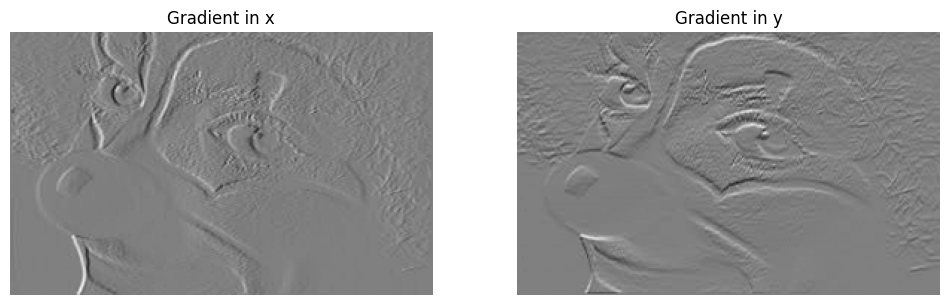

grad_x min: -0.8333334 max: 0.9761905
grad_y min: -0.72619057 max: 0.90079373


In [45]:
# TODO: load image
img_normal = load_gray_normalized(grey_image)

# TODO: define kernels
#Initialize a simple gradient kernel like  [−1,0,+1]  for  dx  (np.zeros, np.array)
#dy = np.zeros_like(img_normal, dtype=float)
#dx = np.zeros_like(img_normal, dtype=float)
# Kernel für x-Richtung horizontaler Gradient
kernel_dx = np.array([[-1, 0, 1]], dtype=np.float32)
# Kernel für y-Richtung vertikaler Gradient
#kernel_dy = np.array([[-1, 0, 1]], dtype=np.float32)
kernel_dy = np.array([[-1], [0], [1]], dtype=np.float32)

# TODO: filter images
#filter the image with it (cv2.filter2D).
grad_x = cv2.filter2D(img_normal, -1, kernel_dx)
grad_y = cv2.filter2D(img_normal, -1, kernel_dy)
#sobel_x = cv2.Sobel(img_normal, cv2.CV_64F, 1, 0, ksize=3)
#sobel_y = cv2.Sobel(img_normal, cv2.CV_64F, 0, 1, ksize=3)

#vmin = min(grad_x.min(), grad_y.min())
#vmax = max(grad_x.max(), grad_y.max())

#grad_x_norm = (grad_x - grad_x.min()) / (grad_x.max() - grad_x.min())
#grad_y_norm = (grad_y - grad_y.min()) / (grad_y.max() - grad_y.min())

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
#axes[0].imshow(grad_x, cmap='gray', vmin=vmin, vmax=vmax)
#axes[1].imshow(grad_y, cmap='gray', vmin=vmin, vmax=vmax)

# TODO: display images
#Visualize the results using plt.imshow. To this end, display the resulting images of both derivatives along x and y in a single figure (plt.subplots)
#plt.imshow(img_normal)

plt.subplot(1, 2, 1)
#plt.imshow(grad_x, cmap='gray')  # kein vmin/vmax
plt.imshow(grad_x, cmap='gray', vmin=-1, vmax=1)
plt.title('Gradient in x')
plt.axis('off')

plt.subplot(1, 2, 2)
#plt.imshow(grad_y, cmap='gray')
plt.imshow(grad_y, cmap='gray', vmin=-1, vmax=1)
plt.title('Gradient in y')
plt.axis('off')


plt.show()

print("grad_x min:", grad_x.min(), "max:", grad_x.max())
print("grad_y min:", grad_y.min(), "max:", grad_y.max())

#print("grad_x min norm:", grad_x_norm.min(), "max:", grad_x_norm.max())
#print("grad_y min norm:", grad_y_norm.min(), "max:", grad_y_norm.max())
#What do you need to take care of, to be able to visually compare the results? Hint: the problem is related to the range of the pixel values in the two gradient images. Name the problem and propose a solution to it by using the options of the plt.imshow function.
#"Das Problem ist, dass plt.imshow ohne vmin/vmax jeden Bildkanal individuell skaliert. Die Lösung ist, vmin und vmax für beide Bilder gleich zu setzen (z.B. vmin=-1, vmax=1), damit die Grauwerte direkt vergleichbar sind. In diesem konkreten Fall ist der Unterschied gering, da beide Gradientenbilder ähnliche Wertebereiche haben."

## Exercise 1.3
### Point operations
Download from the website the images `ueb131.png` and `ueb132.png`,
then load and display them.  
Both images illustrate two commonly encountered problems in photography.
Underexposed (overexposed) images are darker (brighter) than they should be,
because they have been exposed to too little (too much) light.

Compute and display the histograms (`plt.hist`,`np.flatten`) of the images in range $[0,1]$. Write a function `display_with_hist` that creates two subplots, showing the image and the respective histogram.

Can you identify the exposure problems in the histograms?
Hint: look at how the pixel intensities are distributed.

These defects can be corrected by remapping the pixel values to achieve a
more evenly distributed range of pixel intensities.
This can either be done by using histogram equalization (`cv2.equalizeHist`) or by using the logarithmic and power functions.

To use `cv2.equalizeHist`, the images need to be casted to uint8 in $[0,255]$. Write a function `normalized_to_uint8` to do this.

Apply the logarithmic and power to improve the two images. Experiment with different bases for the logarithm and power. To get a better feeling for the problem, plot the functions $x^2$ in $[0,1]$ and $log(x)$ in $[1,255]$ (why not $[0, 255]$?, `np.linspace, np.log, plt.plot`). **Where do the functions change quickly, where do they change slowly? How can you use this knowledge to improve the images?**

In [46]:
def display_with_hist(image, title="Image"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

      # linkes Subplot: Bild anzeigen
    axes[0].imshow(image, cmap='gray')
    axes[0].axis('off')
    axes[0].set_title(title)

      # rechtes Subplot: Histogramm
    axes[1].hist(image.flatten(), bins=256, range=[0, 1])
    axes[1].set_title('Histogram')
    axes[1].set_xlabel('Pixel intensity [0,1]')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

In [59]:
def normalized_to_uint8(image):
    return (image * 255).astype(np.uint8)
    #pass

Min: 0.0 voerher Min: 0
Max: 1.0 vorher Max: 255
Min: 0.0 voerher Min: 0
Max: 1.0 vorher Max: 255


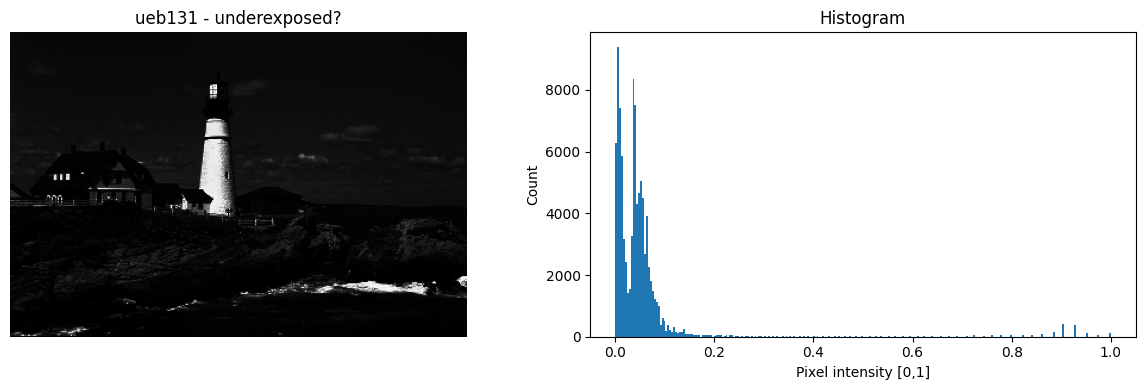

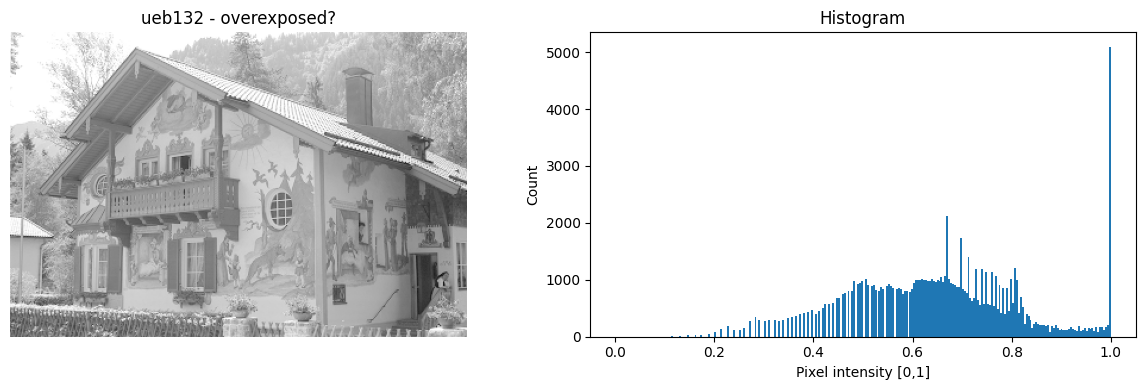

In [53]:
# TODO: load images

img1 = load_gray_normalized(load_image_from_link('ueb131'))
img2 = load_gray_normalized(load_image_from_link('ueb132'))

# Anzeigen mit Histogramm
display_with_hist(img1, title="ueb131 - underexposed?")
display_with_hist(img2, title="ueb132 - overexposed?")
# TODO: display images with histograms


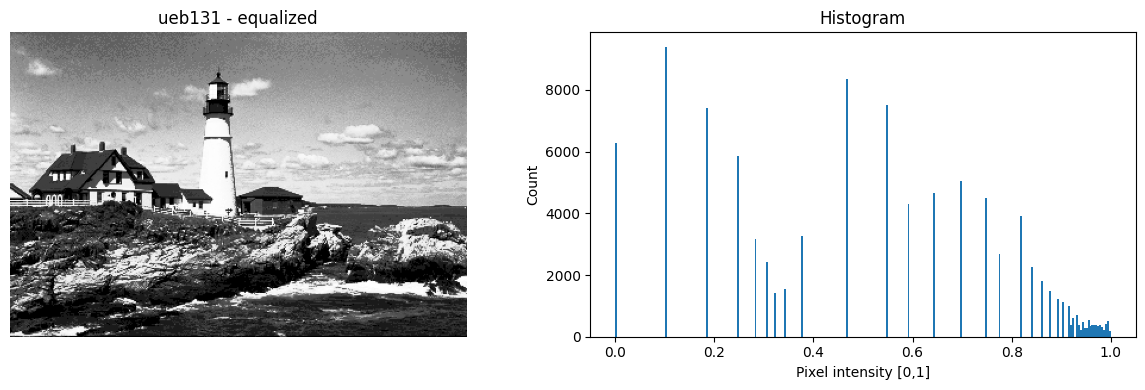

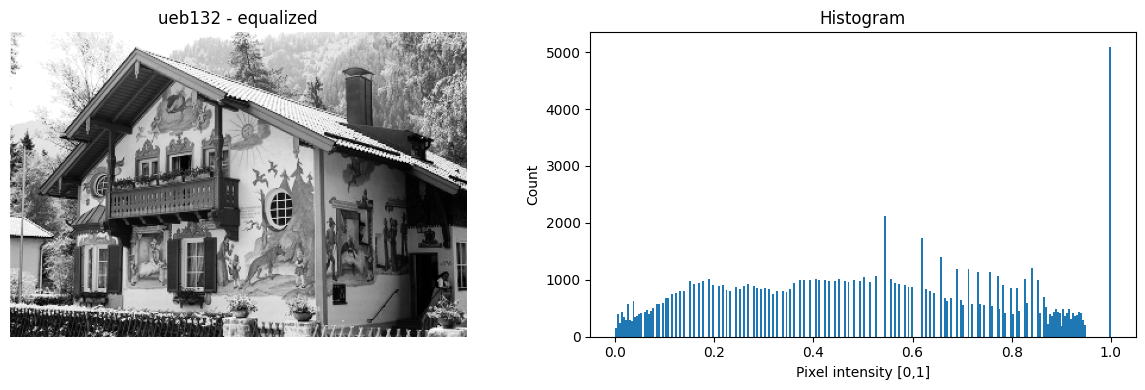

In [61]:
# TODO: convert images to uint8
img1_uint8 = normalized_to_uint8(img1)
img2_uint8 = normalized_to_uint8(img2)

# TODO: equalize histogram and display
img1_eq = cv2.equalizeHist(img1_uint8)
img2_eq = cv2.equalizeHist(img2_uint8)

display_with_hist(img1_eq / 255.0, title="ueb131 - equalized")
display_with_hist(img2_eq / 255.0, title="ueb132 - equalized")
#print(type(img1_uint8))
#print(img1_uint8.dtype)
#print(img1_uint8.shape)

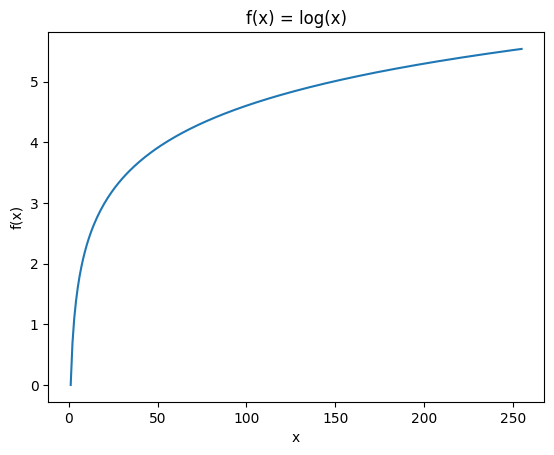

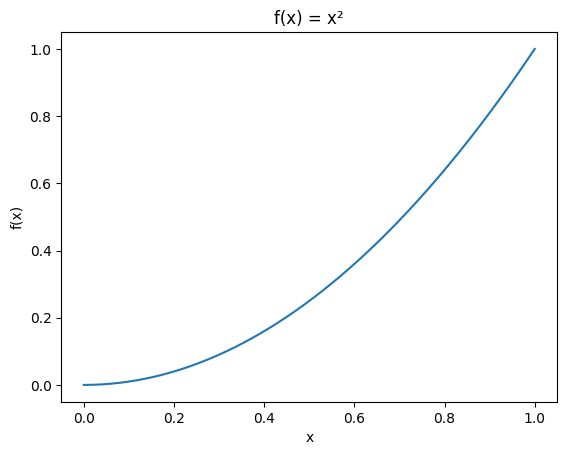

In [62]:
# TODO: display logarithmic function
x_log = np.linspace(1, 255, 256)  # nicht 0, weil log(0) = -unendlich!
plt.plot(x_log, np.log(x_log))
plt.title('f(x) = log(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()
# TODO: display quadratic function
x_quad = np.linspace(0, 1, 256)
plt.plot(x_quad, x_quad**2)
plt.title('f(x) = x²')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

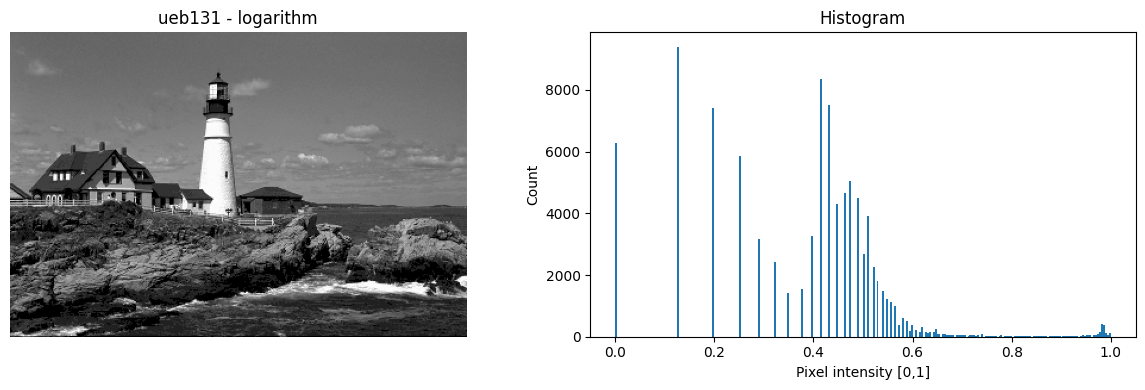

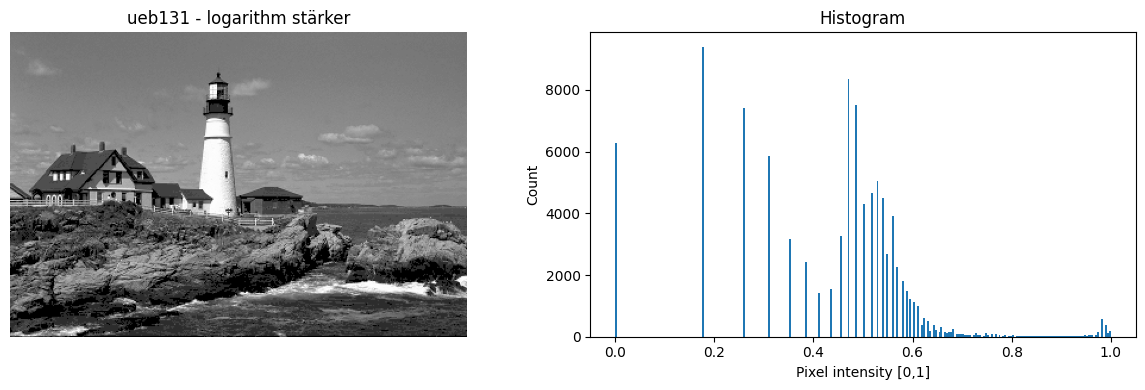

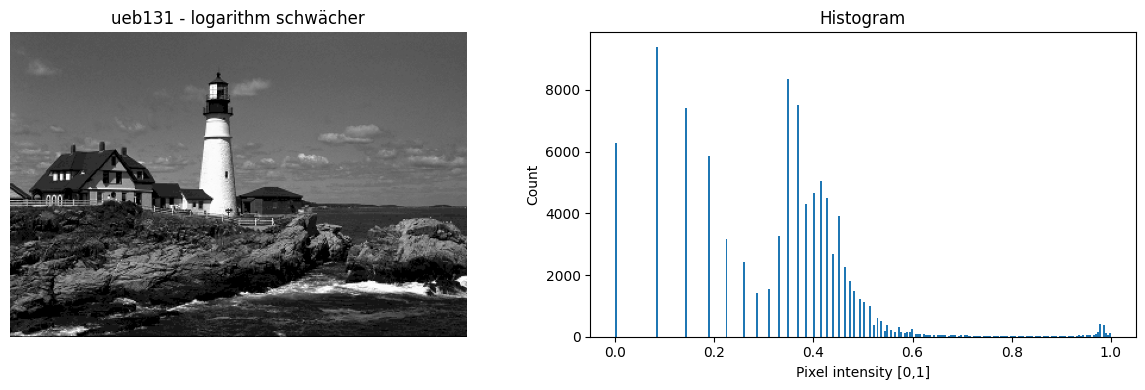

In [65]:
# TODO: transform and display ueb131.png
img1_uint8 = normalized_to_uint8(img1)

# Logarithmus anwenden (experimentiere mit dem Faktor!)
img1_log = np.log(img1_uint8.astype(np.float32) + 1)  # +1 wegen log(0)!
img1_log = img1_log / img1_log.max()  # normalisieren auf [0,1]

display_with_hist(img1_log, title="ueb131 - logarithm")
# Stärkerer Effekt: höherer Faktor vor dem log
img1_log2 = np.log(img1_uint8.astype(np.float32) * 2 + 1)
img1_log2 = img1_log2 / img1_log2.max()
display_with_hist(img1_log2, title="ueb131 - logarithm stärker")

# Schwächerer Effekt
img1_log3 = np.log(img1_uint8.astype(np.float32) * 0.5 + 1)
img1_log3 = img1_log3 / img1_log3.max()
display_with_hist(img1_log3, title="ueb131 - logarithm schwächer")

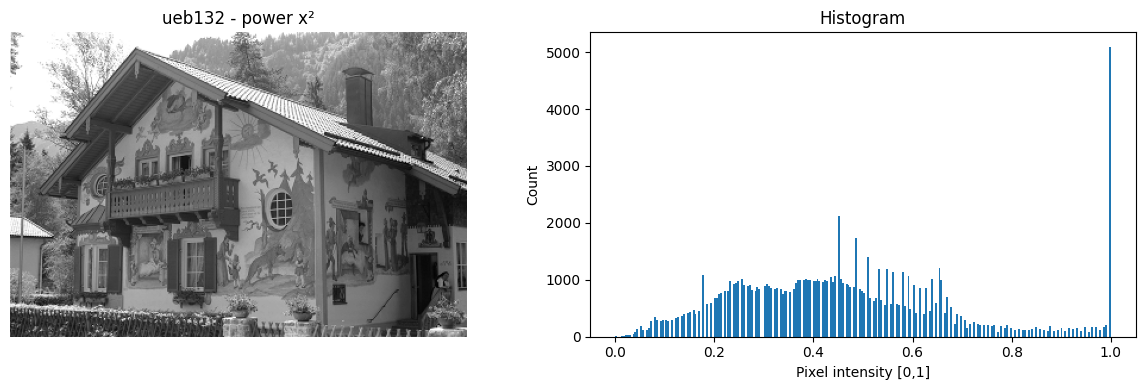

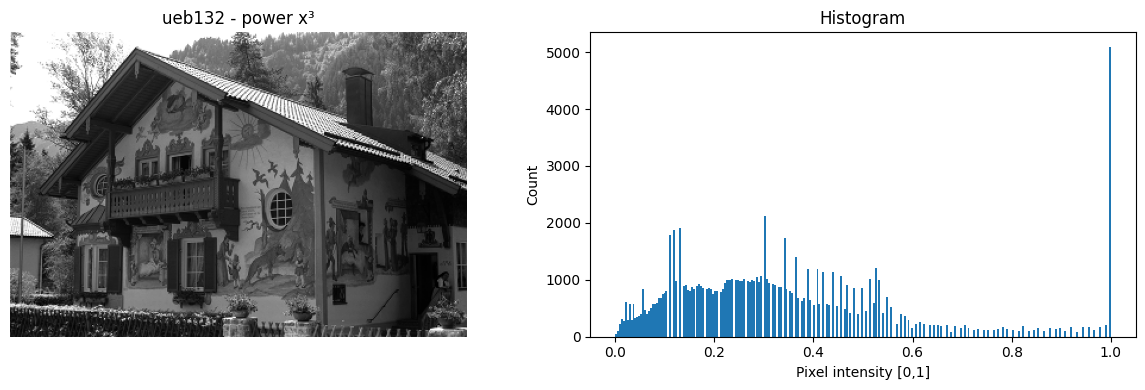

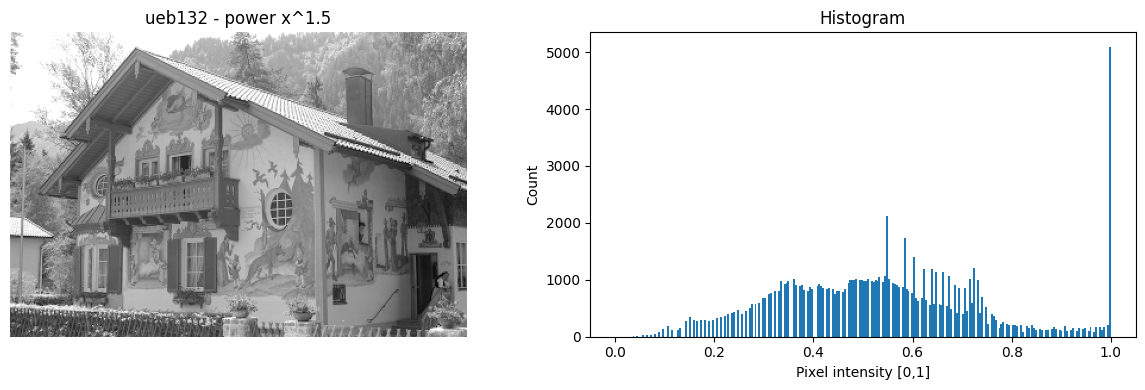

In [64]:
# TODO: transform and display ueb132.png

# Potenz anwenden (experimentiere mit dem Exponenten!)
img2_power = img2 ** 2  # img2 ist schon in [0,1]
display_with_hist(img2_power, title="ueb132 - power x²")

# Stärkerer Effekt
img2_power2 = img2 ** 3
display_with_hist(img2_power2, title="ueb132 - power x³")

# Schwächerer Effekt
img2_power3 = img2 ** 1.5
display_with_hist(img2_power3, title="ueb132 - power x^1.5")